In [2]:
# import os
# sim_path = os.path.abspath(os.path.join("..", "src", "simulation"))
# if sim_path not in sys.path:
#     sys.path.insert(0, sim_path)

In [1]:
import os
import sys

# 1. Thêm đường dẫn hiện tại và thư mục jetracer vào sys.path
current_dir = os.getcwd()
sys.path.insert(0, current_dir)
sys.path.insert(0, os.path.join(current_dir, 'jetracer'))

In [2]:
import sys
import os
import cv2
import numpy as np
import onnxruntime as ort
import rospy
from sensor_msgs.msg import Image
from jetracer.nvidia_racecar import NvidiaRacecar

print(f"[+] ONNX Runtime Version: {ort.__version__}")

# Kiểm tra các Provider xử lý (Ưu tiên CUDA/TensorRT)
available_providers = ort.get_available_providers()
print(f"[+] Available Providers: {available_providers}")

if 'CUDAExecutionProvider' in available_providers:
    print("[✓] Đã sẵn sàng chạy ONNX trên GPU (CUDA)!")
else:
    print("[!] Cảnh báo: Không tìm thấy CUDA Provider, mô hình sẽ chạy bằng CPU.")

[+] ONNX Runtime Version: 1.10.0
[+] Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
[✓] Đã sẵn sàng chạy ONNX trên GPU (CUDA)!


WARNNIG: Jetson.GPIO library has not been verified with this carrier board,


In [3]:
import gc
import time
import cv2
import numpy as np
import rospy
from IPython.display import Image, clear_output, display

from smart_city.camera_steam import CameraStream 
from smart_city.processor import YOLOProcessor, RoadProcessor
from smart_city.traffic_fsm import TrafficFSM
from smart_city.onnx_engine import ONNXEngine
from smart_city.controller import RacecarController
from smart_city.dashboard import render_dashboard
from smart_city.lane_follower import LaneFollower
from smart_city.navigation_fsm import NavigationFSM

# khởi tạo cam
cam = CameraStream(
    topic_name='/csi_cam_0/image_raw', width=640, height=480, record_video=False
)

# 1. Khởi tạo Engine
traffic_engine = ONNXEngine('../models/traffic.onnx')
# traffic_engine = ONNXEngine('../models/best.onnx')
road_engine = ONNXEngine('../models/best_model_mobilenet.onnx')

# 2. Khởi tạo Processor riêng biệt
traffic_processor = YOLOProcessor(img_size=(640))
road_processor = RoadProcessor(img_size=(224, 224), threshold=0.5)

print("✅ Đã nạp thành công Model ONNX và Khởi tạo Processor!")

[INFO] [1787321787.533174]: 📷 Đã Subscribe vào Topic: /csi_cam_0/image_raw
💡 ONNXEngine đang chạy trên: TensorrtExecutionProvider
💡 ONNXEngine đang chạy trên: TensorrtExecutionProvider
✅ Đã nạp thành công Model ONNX và Khởi tạo Processor!


In [4]:
from smart_city.controller import RacecarController

car = RacecarController(base_throttle=0.15)

In [5]:
car.stop()

In [6]:
import gc, time, cv2, rospy, threading, queue, ipywidgets as w, logging
from IPython.display import display

# --- 1. KHỞI TẠO CẤU HÌNH & FSM ---
fsm = TrafficFSM(
    conf_threshold=0.7,
    min_consecutive_frames=5,
    min_bbox_area_sign=2500,
    min_bbox_area_traffic_light=800,
    roi_x_min=0,
    roi_x_max=1
)

nav_fsm = NavigationFSM(confirm_frames=3, block_threshold=0.9, stop_timeout=30.0, max_reverse_cycles=2)

# Trạng thái toàn cục
is_running = False
is_loop_active = False
last_logged_state = None

# Road-block AI (bám làn / né vật cản) chạy MỖI FRAME trong loop chính -> không stride nữa.
# YOLO (traffic sign/light) chạy ở thread riêng, tốc độ bao nhiêu tùy nó, main loop không chờ.
VIS_STRIDE = 2
GC_INTERVAL_FRAMES = 2000
LOG_LOOP_TIME_EVERY = 40
TRAFFIC_AI_STALE_WARN_SEC = 1.0   # cảnh báo nếu kết quả YOLO cũ hơn ngưỡng này

# --- 2. GIAO DIỆN UI ---
btn_start = w.Button(description="🚀 START", button_style='success', layout=w.Layout(width='150px'))
btn_stop = w.Button(description="🛑 STOP", button_style='danger', layout=w.Layout(width='150px'))
image_widget = w.Image(format='jpeg', width=640)

def on_start_clicked(b):
    global is_running
    is_running = True
    nav_fsm.reset()
    rospy.loginfo("▶️ Bấm START: Xe BẮT ĐẦU chạy!")

def on_stop_clicked(b):
    global is_running
    is_running = False
    car.stop()
    rospy.loginfo("⏸️ Bấm STOP: Xe ĐÃ DỪNG!")

btn_start.on_click(on_start_clicked)
btn_stop.on_click(on_stop_clicked)

display(w.HBox([btn_start, btn_stop]))
display(image_widget)

# --- HELPER: XÁC ĐỊNH HƯỚNG RẼ ƯU TIÊN ---
# def resolve_intended_direction(allowed_dirs):
#     if not allowed_dirs or "STOP" in allowed_dirs:
#         return "STOP"
#     if "FORWARD" in allowed_dirs or "STRAIGHT" in allowed_dirs or "GO_STRAIGHT" in allowed_dirs:
#         return "FORWARD"
#     if "RIGHT" in allowed_dirs or "TURN_RIGHT" in allowed_dirs:
#         return "RIGHT"
#     if "LEFT" in allowed_dirs or "TURN_LEFT" in allowed_dirs:
#         return "LEFT"
#     return "STOP"
def resolve_intended_direction(allowed_dirs, last_turn_dir="RIGHT"):
    """
    Xác định hướng di chuyển ưu tiên:
    1. Trả về STOP nếu có lệnh dừng hoặc không có lệnh di chuyển.
    2. Ưu tiên đi thẳng (FORWARD) lên hàng đầu nếu được phép.
    3. Nếu không có lệnh đi thẳng, ưu tiên rẽ theo hướng rẽ gần nhất (last_turn_dir).
    """
    if not allowed_dirs or "STOP" in allowed_dirs:
        return "STOP"

    # Kiểm tra các hướng có trong danh sách cho phép
    has_forward = any(d in allowed_dirs for d in ["FORWARD", "STRAIGHT", "GO_STRAIGHT", "MOVE_FORWARD"])
    has_right = any(d in allowed_dirs for d in ["RIGHT", "TURN_RIGHT"])
    has_left = any(d in allowed_dirs for d in ["LEFT", "TURN_LEFT"])

    # 1. ƯU TIÊN #1: Đi thẳng (mặc kệ last_turn_dir)
    if has_forward:
        return "FORWARD"

    # 2. ƯU TIÊN #2: Nếu được phép cả Rẽ Trái và Rẽ Phải -> Ưu tiên theo last_turn_dir
    if has_right and has_left:
        return "RIGHT" if last_turn_dir == "RIGHT" else "LEFT"
    elif has_right:
        return "RIGHT"
    elif has_left:
        return "LEFT"

    return "STOP"

# =========================================================================
# 3. THREAD RIÊNG CHO CAMERA CAPTURE (producer)
# =========================================================================
class LatestFrameBuffer:
    def __init__(self):
        self._frame = None
        self._frame_id = 0
        self._lock = threading.Lock()
        self._new_frame_event = threading.Event()

    def set(self, frame):
        with self._lock:
            self._frame = frame
            self._frame_id += 1
        self._new_frame_event.set()

    def get_latest(self, last_seen_id):
        with self._lock:
            if self._frame_id != last_seen_id:
                return self._frame, self._frame_id
            return None, last_seen_id

    def wait_new_frame(self, timeout=0.5):
        self._new_frame_event.wait(timeout)
        self._new_frame_event.clear()


frame_buffer = LatestFrameBuffer()
cam_fps_counter = {"count": 0, "t0": None}

def camera_capture_loop():
    cam_fps_counter["t0"] = rospy.get_time()
    while is_loop_active and not rospy.is_shutdown():
        frame = cam.get_frame()
        if frame is not None:
            frame_buffer.set(frame)
            cam_fps_counter["count"] += 1
        else:
            time.sleep(0.005)

        elapsed = rospy.get_time() - cam_fps_counter["t0"]
        if elapsed >= 5.0:
            fps = cam_fps_counter["count"] / elapsed
            rospy.loginfo(f"[CAM] Camera capture FPS thực tế: {fps:.1f}")
            cam_fps_counter["count"] = 0
            cam_fps_counter["t0"] = rospy.get_time()

cam_thread = threading.Thread(target=camera_capture_loop, daemon=True)


# =========================================================================
# 4. THREAD RIÊNG CHO YOLO (traffic sign / traffic light) — ƯU TIÊN THẤP HƠN
# =========================================================================
# Lý do tách ra: YOLO có thể chậm hơn road-block AI (model nặng hơn, nhiều
# class hơn). Nếu để chung loop chính thì mỗi khi YOLO chậm, cả xe bị delay
# theo -> ảnh hưởng trực tiếp tới bám làn / né vật cản (thứ quan trọng hơn
# nhiều về an toàn). Nên: YOLO chạy độc lập, hết khả năng tới đâu thì chạy
# tới đó (best-effort), và loop chính CHỈ ĐỌC kết quả mới nhất có sẵn,
# không bao giờ chờ / block vì YOLO.

class TrafficAIResultBox:
    """Hộp thư kết quả YOLO mới nhất, thread-safe, có timestamp để biết độ 'cũ'."""
    def __init__(self):
        self._allowed_dirs = []
        self._detections = []
        self._timestamp = 0.0
        self._lock = threading.Lock()

    def set(self, allowed_dirs, detections, timestamp):
        with self._lock:
            self._allowed_dirs = allowed_dirs
            self._detections = detections
            self._timestamp = timestamp

    def get(self):
        with self._lock:
            return self._allowed_dirs, self._detections, self._timestamp


traffic_result_box = TrafficAIResultBox()
traffic_fps_counter = {"count": 0, "t0": None}

def traffic_ai_loop():
    """Thread riêng: liên tục lấy frame mới nhất và chạy YOLO, publish kết quả, không giới hạn theo loop chính."""
    global is_loop_active
    traffic_fps_counter["t0"] = rospy.get_time()
    last_frame_id = 0
    while is_loop_active and not rospy.is_shutdown():
        frame, frame_id = frame_buffer.get_latest(last_frame_id)
        if frame is None:
            frame_buffer.wait_new_frame(timeout=0.1)
            frame, frame_id = frame_buffer.get_latest(last_frame_id)
            if frame is None:
                continue
        last_frame_id = frame_id

        t_input, orig_h, orig_w = traffic_processor.preprocess(frame)
        detections = traffic_processor.postprocess(traffic_engine.infer(t_input), orig_h, orig_w)
        allowed_dirs = fsm.update(detections, img_w=orig_w, img_h=orig_h)
        traffic_result_box.set(allowed_dirs, detections, rospy.get_time())

        traffic_fps_counter["count"] += 1
        elapsed = rospy.get_time() - traffic_fps_counter["t0"]
        if elapsed >= 5.0:
            fps = traffic_fps_counter["count"] / elapsed
            rospy.loginfo(f"[YOLO] Traffic AI FPS thực tế: {fps:.1f}")
            traffic_fps_counter["count"] = 0
            traffic_fps_counter["t0"] = rospy.get_time()

traffic_ai_thread = threading.Thread(target=traffic_ai_loop, daemon=True)


# =========================================================================
# 5. THREAD RIÊNG CHO VISUALIZATION (consumer, tách khỏi loop điều khiển)
# =========================================================================
vis_queue = queue.Queue(maxsize=1)

def vis_worker():
    while is_loop_active:
        try:
            vis_frame, maneuver_state, blocked_cnt, intended_dir, steer, thr, running, stale = vis_queue.get(timeout=0.5)
        except queue.Empty:
            continue
        color = (0, 255, 0) if running else (0, 0, 255)
        cv2.putText(vis_frame, f"Mode: {maneuver_state} | BlkCnt: {blocked_cnt}",
                    (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        dir_color = (0, 0, 255) if stale else (255, 255, 0)
        stale_tag = " [STALE]" if stale else ""
        cv2.putText(vis_frame, f"Intended Dir: {intended_dir}{stale_tag} | Steer: {steer:+.2f} | Thr: {thr:.2f}",
                    (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.55, dir_color, 2)
        ok, buf = cv2.imencode('.jpg', vis_frame, [cv2.IMWRITE_JPEG_QUALITY, 70])
        if ok:
            image_widget.value = buf.tobytes()

vis_thread = threading.Thread(target=vis_worker, daemon=True)


# =========================================================================
# 6. LOOP CHÍNH: ƯU TIÊN ROAD-BLOCK AI (bám làn/né vật cản) MỖI FRAME.
#    YOLO/hướng rẽ chỉ đọc cache, KHÔNG chờ, KHÔNG chặn control loop.
# =========================================================================
def camera_control_loop():
    global is_running, is_loop_active, last_logged_state

    rate, frame_count = rospy.Rate(20), 0
    last_frame_id = 0

    try:
        while is_loop_active and not rospy.is_shutdown():
            t_loop_start = rospy.get_time()

            # --- Lấy frame MỚI NHẤT từ buffer ---
            frame, frame_id = frame_buffer.get_latest(last_frame_id)
            if frame is None:
                frame_buffer.wait_new_frame(timeout=0.1)
                frame, frame_id = frame_buffer.get_latest(last_frame_id)
                if frame is None:
                    car.stop()
                    rate.sleep()
                    continue
            last_frame_id = frame_id

            frame_count += 1
            now = rospy.get_time()

            # --- A. ROAD-BLOCK AI: ƯU TIÊN #1, chạy MỖI FRAME, không stride ---
            # Đây là input trực tiếp cho bám làn / né vật cản -> cần fresh nhất có thể.
            r_input = road_processor.preprocess(frame)
            raw_road_out = road_engine.infer(r_input)
            road_res = road_processor.postprocess(raw_road_out)
            prob_blocked = road_res['blocked_probability']

            # --- B. HƯỚNG RẼ TỪ YOLO: đọc cache mới nhất, KHÔNG chờ YOLO ---
            allowed_dirs, detections, traffic_ts = traffic_result_box.get()
            intended_dir = resolve_intended_direction(allowed_dirs)
            traffic_stale = (now - traffic_ts) > TRAFFIC_AI_STALE_WARN_SEC if traffic_ts else True

            # --- C. ĐIỀU KHIỂN XE QUA NAVIGATION FSM ---
            if is_running:
                maneuver_state, blocked_cnt = nav_fsm.update(intended_dir, prob_blocked, car, now)
            else:
                car.stop()
                maneuver_state, blocked_cnt = 'PAUSE', 0

            # --- D. LOG DEBUG CONSOLE (chỉ khi trạng thái đổi) ---
            current_state = (is_running, maneuver_state, blocked_cnt, tuple(allowed_dirs),
                              car.car.steering, car.car.throttle)
            if current_state != last_logged_state:
                status_tag = "RUNNING" if is_running else "PAUSED"
                stale_tag = " (YOLO STALE)" if traffic_stale else ""
                rospy.loginfo(f"[{status_tag}] NavState: {maneuver_state} | BlkCnt: {blocked_cnt} | "
                              f"Dir: {intended_dir}{stale_tag} | Steer: {car.car.steering:.2f} | Thr: {car.car.throttle:.2f}")
                last_logged_state = current_state

            # --- E. ĐẨY FRAME SANG THREAD VISUALIZATION (không chờ encode) ---
            if frame_count % VIS_STRIDE == 0:
                vis_frame = frame.copy()
                for d in detections:
                    if d.get("confidence", 0) >= fsm.conf_threshold:
                        b = d.get("bbox") or d.get("box")
                        if "box" in d:
                            x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[0] + b[2]), int(b[1] + b[3])
                        else:
                            x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[2]), int(b[3])
                        cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

                payload = (vis_frame, maneuver_state, blocked_cnt, intended_dir,
                           car.car.steering, car.car.throttle, is_running, traffic_stale)
                if vis_queue.full():
                    try:
                        vis_queue.get_nowait()
                    except queue.Empty:
                        pass
                vis_queue.put_nowait(payload)

            # --- F. GC: giãn rất thưa ---
            if frame_count % GC_INTERVAL_FRAMES == 0:
                gc.collect(generation=0)

            # --- G. THEO DÕI HIỆU NĂNG LOOP AI/ĐIỀU KHIỂN ---
            loop_time = rospy.get_time() - t_loop_start
            if frame_count % LOG_LOOP_TIME_EVERY == 0:
                rospy.loginfo(f"[PERF] AI loop_time={loop_time*1000:.1f}ms (~{1.0/max(loop_time,1e-6):.1f}Hz)")

            rate.sleep()

    finally:
        car.stop()
        rospy.loginfo('🛑 Dừng xe an toàn.')


# --- 7. KÍCH HOẠT CÁC THREAD ---
# Thứ tự: camera trước (để có frame sẵn) -> YOLO (best-effort, ưu tiên thấp)
# -> vis -> loop chính (road-block AI, ưu tiên cao nhất, chạy realtime).
is_loop_active = True
cam_thread.start()
traffic_ai_thread.start()
vis_thread.start()
thread = threading.Thread(target=camera_control_loop, daemon=True)
thread.start()

Image(value=b'', format='jpeg', width='640')

[INFO] [1787321810.987581]: [PAUSED] NavState: PAUSE | BlkCnt: 0 | Dir: STOP (YOLO STALE) | Steer: 0.00 | Thr: 0.00
[INFO] [1787321811.319345]: [PAUSED] NavState: PAUSE | BlkCnt: 0 | Dir: FORWARD | Steer: 0.00 | Thr: 0.00
[INFO] [1787321812.954439]: [PERF] AI loop_time=23.6ms (~42.4Hz)
[INFO] [1787321813.097405]: [CAM] Camera capture FPS thực tế: 1625.9
[INFO] [1787321813.350536]: [YOLO] Traffic AI FPS thực tế: 1.1
[INFO] [1787321814.952398]: [PERF] AI loop_time=21.6ms (~46.2Hz)
[INFO] [1787321816.977189]: [PERF] AI loop_time=46.4ms (~21.5Hz)
[INFO] [1787321818.125224]: [CAM] Camera capture FPS thực tế: 894.0
[INFO] [1787321818.624001]: [YOLO] Traffic AI FPS thực tế: 2.5
[INFO] [1787321818.960517]: [PERF] AI loop_time=28.1ms (~35.6Hz)
[INFO] [1787321820.954623]: [PERF] AI loop_time=23.9ms (~41.9Hz)
[INFO] [1787321822.961899]: [PERF] AI loop_time=29.1ms (~34.4Hz)
[INFO] [1787321823.137388]: [CAM] Camera capture FPS thực tế: 919.0
[INFO] [1787321823.829494]: [YOLO] Traffic AI FPS thực tế

In [5]:
import gc, time, cv2, rospy, threading, ipywidgets as w, logging
from IPython.display import display

# --- 1. KHỞI TẠO CẤU HÌNH & FSM ---
fsm = TrafficFSM(
    conf_threshold=0.5, 
    min_consecutive_frames=5, 
    min_bbox_area_sign=2000, 
    min_bbox_area_traffic_light=800, 
    roi_x_min=0.05, 
    roi_x_max=0.95
)

# Khởi tạo Navigation FSM xử lý thoát kẹt & mở góc cua
nav_fsm = NavigationFSM(confirm_frames=3, block_threshold=0.9)

# Trạng thái toàn cục
is_running = False
is_loop_active = False
last_logged_state = None

# --- 2. TẠO GIAO DIỆN UI NÚT BẤM ---
btn_start = w.Button(description="🚀 START", button_style='success', layout=w.Layout(width='150px'))
btn_stop = w.Button(description="🛑 STOP", button_style='danger', layout=w.Layout(width='150px'))
image_widget = w.Image(format='jpeg', width=640)

def on_start_clicked(b):
    global is_running
    is_running = True
    nav_fsm.reset()  # Reset trạng thái FSM về DRIVE khi bấm START
    rospy.loginfo("▶️ Bấm START: Xe BẮT ĐẦU chạy!")

def on_stop_clicked(b):
    global is_running
    is_running = False
    car.stop()
    rospy.loginfo("⏸️ Bấm STOP: Xe ĐÃ DỪNG!")

btn_start.on_click(on_start_clicked)
btn_stop.on_click(on_stop_clicked)

display(w.HBox([btn_start, btn_stop]))
display(image_widget)

# --- HELPER FUNCTION: XÁC ĐỊNH HƯỚNG RẼ ƯU TIÊN ---
def resolve_intended_direction(allowed_dirs):
    if not allowed_dirs or "STOP" in allowed_dirs:
        return "STOP"
    if "FORWARD" in allowed_dirs or "STRAIGHT" in allowed_dirs or "GO_STRAIGHT" in allowed_dirs:
        return "FORWARD"
    if "RIGHT" in allowed_dirs or "TURN_RIGHT" in allowed_dirs:
        return "RIGHT"
    if "LEFT" in allowed_dirs or "TURN_LEFT" in allowed_dirs:
        return "LEFT"
    return "STOP"

# --- 3. VÒNG LẶP CHẠY TRÊN THREAD PHỤ ---
def camera_control_loop():
    global is_running, is_loop_active, last_logged_state
    
    rate, frame_count = rospy.Rate(20), 0
    prob_blocked = 0.0  # Lưu bộ đệm xác suất vật cản

    try:
        while is_loop_active and not rospy.is_shutdown():
            frame = cam.get_frame()
            if frame is None:
                car.stop()
                rate.sleep()
                continue

            frame_count += 1
            now = rospy.get_time()

            # --- A. TRAFFIC AI INFERENCE (Chạy liên tục mỗi frame) ---
            t_input, orig_h, orig_w = traffic_processor.preprocess(frame)
            detections = traffic_processor.postprocess(traffic_engine.infer(t_input), orig_h, orig_w)
            allowed_dirs = fsm.update(detections, img_w=orig_w, img_h=orig_h)

            # --- B. HƯỚNG ĐI & ROAD BLOCK AI (Giảm tải: Chạy Road AI 4 frame/lần ~ 5Hz) ---
            intended_dir = resolve_intended_direction(allowed_dirs)

            # if frame_count % 1 == 0:
            r_input = road_processor.preprocess(frame)
            raw_road_out = road_engine.infer(r_input)
            road_res = road_processor.postprocess(raw_road_out)
            prob_blocked = road_res['blocked_probability']

            # --- C. ĐIỀU KHIỂN XE QUA NAVIGATION FSM ---
            if is_running:
                maneuver_state, blocked_cnt = nav_fsm.update(intended_dir, prob_blocked, car, now)
            else:
                car.stop()
                maneuver_state, blocked_cnt = 'PAUSE', 0

            # --- D. LOG DEBUG CONSOLE ---
            current_state = (is_running, maneuver_state, blocked_cnt, tuple(allowed_dirs), car.car.steering, car.car.throttle)
            if current_state != last_logged_state:
                status_tag = "RUNNING" if is_running else "PAUSED"
                rospy.loginfo(f"[{status_tag}] NavState: {maneuver_state} | BlkCnt: {blocked_cnt} | Dir: {intended_dir} | Steer: {car.car.steering:.2f} | Thr: {car.car.throttle:.2f}")
                last_logged_state = current_state

            # --- E. VISUALIZATION OVERLAY (Giảm tải: Encode UI 2 frame/lần) ---
            if frame_count % 2 == 0:
                vis_frame = frame.copy()
                for d in detections:
                    if d.get("confidence", 0) >= fsm.conf_threshold:
                        b = d.get("bbox") or d.get("box")
                        x1, y1, x2, y2 = (int(b[0]), int(b[1]), int(b[0]+b[2]), int(b[1]+b[3])) if "box" in d else (int(b[0]), int(b[1]), int(b[2]), int(b[3]))
                        cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                color = (0, 255, 0) if is_running else (0, 0, 255)
                cv2.putText(vis_frame, f"Mode: {maneuver_state} | BlkCnt: {blocked_cnt}", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                cv2.putText(vis_frame, f"Intended Dir: {intended_dir} | Steer: {car.car.steering:+.2f} | Thr: {car.car.throttle:.2f}", (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)

                image_widget.value = cv2.imencode('.jpg', vis_frame)[1].tobytes()

            if frame_count % 100 == 0: 
                gc.collect()

            rate.sleep()

    finally:
        car.stop()
        rospy.loginfo('🛑 Dừng xe an toàn.')

# --- 4. KÍCH HOẠT THREAD ---
is_loop_active = True
thread = threading.Thread(target=camera_control_loop, daemon=True)
thread.start()

Image(value=b'', format='jpeg', width='640')

[INFO] [1787298728.157434]: [PAUSED] NavState: PAUSE | BlkCnt: 0 | Dir: FORWARD | Steer: 0.00 | Thr: 0.00


In [7]:
import time
import cv2
import gc
import rospy
import ipywidgets as w
from IPython.display import display

# --- 1. CẤU HÌNH & KHỞI TẠO TRAFFIC FSM ---
DISPLAY_UI, SKIP_FRAMES, TARGET_FPS = True, 1, 20

fsm = TrafficFSM(
    conf_threshold=0.5, 
    min_consecutive_frames=5, 
    min_bbox_area_sign=2000, 
    min_bbox_area_traffic_light=1000, 
    roi_x_min=0.05, 
    roi_x_max=0.95
)

# Khởi tạo widget duy nhất 1 lần để render realtime
image_widget = w.Image(format='jpeg', width=640)
if DISPLAY_UI:
    display(image_widget)

rate = rospy.Rate(TARGET_FPS)
frame_count = 0

rospy.loginfo('🚀 Bắt đầu Real-time Camera Stream - Test TrafficFSM...')

# --- 2. VÒNG LẶP XỬ LÝ THEO THỜI GIAN THỰC ---
try:
    while not rospy.is_shutdown():
        # Đọc frame trực tiếp từ camera xe
        frame = cam.get_frame()
        if frame is None:
            rospy.logwarn_throttle(2.0, '⏳ Đang chờ khung hình từ Camera...')
            rate.sleep()
            continue

        start_time = rospy.get_time()
        frame_count += 1

        # --- A. AI INFERENCE (TRAFFIC DETECTION) ---
        t_input, orig_h, orig_w = traffic_processor.preprocess(frame)
        detections = traffic_processor.postprocess(
            traffic_engine.infer(t_input), orig_h, orig_w
        )

        # --- B. CẬP NHẬT TRAFFIC FSM ---
        allowed_dirs = fsm.update(detections, img_w=orig_w, img_h=orig_h)

        # --- C. HIỂN THỊ VISUALIZATION DEBUG ---
        latency_ms = (rospy.get_time() - start_time) * 1000
        fps_real = 1000 / max(latency_ms, 1)

        if DISPLAY_UI and (frame_count % SKIP_FRAMES == 0):
            vis_frame = frame.copy()

            # 1. Vẽ vùng ROI X (2 đường dọc màu vàng)
            rx_min, rx_max = int(orig_w * fsm.roi_x_min), int(orig_w * fsm.roi_x_max)
            cv2.line(vis_frame, (rx_min, 0), (rx_min, orig_h), (255, 255, 0), 2)
            cv2.line(vis_frame, (rx_max, 0), (rx_max, orig_h), (255, 255, 0), 2)

            # 2. Bounding Box & Lọc điều kiện FSM
            for d in detections:
                label, conf = d.get("class_name", ""), d.get("confidence", 0)
                b = d.get("bbox") or d.get("box")
                if b is None or conf < fsm.conf_threshold: 
                    continue

                # Xử lý chuẩn định dạng BBox (box: [x,y,w,h] / bbox: [x1,y1,x2,y2])
                if "box" in d:
                    x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[0] + b[2]), int(b[1] + b[3])
                else:
                    x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[2]), int(b[3])

                area, center_x = fsm._parse_box(d, orig_w)
                is_valid = fsm._is_valid_bbox(d, orig_w, orig_h) and (label in fsm.priority)

                # Vẽ màu khung: Xanh lá (Hợp lệ cho FSM), Đỏ (Bị loại trừ)
                color = (0, 255, 0) if is_valid else (0, 0, 255)
                cv2.rectangle(vis_frame, (x1, y1), (x2, y2), color, 2)
                
                # Tag tên nhãn + độ tin cậy + diện tích BBox
                label_text = f"{label} {conf:.2f} ({int(area)}px)"
                cv2.putText(vis_frame, label_text, (x1, max(20, y1 - 5)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

            # 3. Vẽ thông tin FSM Overlay lên góc màn hình
            cv2.putText(vis_frame, f"FPS: {fps_real:.1f} | Latency: {latency_ms:.1f}ms", 
                        (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            status_color = (0, 0, 255) if allowed_dirs == ["STOP"] else (0, 255, 0)
            cv2.putText(vis_frame, f"Allowed Directions: {allowed_dirs}", 
                        (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)

            # 4. Ghi trực tiếp bytes ảnh JPEG vào widget đã khởi tạo
            image_widget.value = cv2.imencode('.jpg', vis_frame)[1].tobytes()

        # Dọn dẹp bộ nhớ định kỳ
        if frame_count % 100 == 0:
            gc.collect()

        rate.sleep()

except KeyboardInterrupt:
    rospy.loginfo('🛑 Đã dừng luồng xem FSM do ngắt bàn phím.')
finally:
    rospy.loginfo('🛑 Kết thúc chương trình.')

Image(value=b'', format='jpeg', width='640')

[INFO] [1787288956.748130]: 🚀 Bắt đầu Real-time Camera Stream - Test TrafficFSM...
[INFO] [1787289188.140975]: 🛑 Đã dừng luồng xem FSM do ngắt bàn phím.
[INFO] [1787289188.393152]: 🛑 Kết thúc chương trình.


In [14]:
car.set_throttle(0)

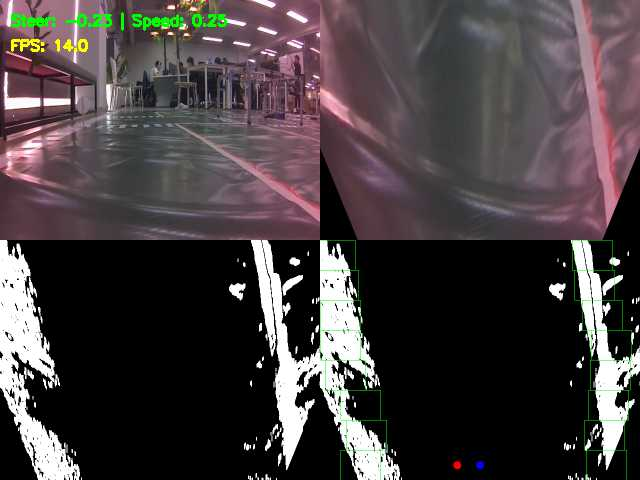

Đang chạy vòng lặp Realtime. Hãy bấm Stop (Icon hình ô vuông) trên Jupyter Toolbar để dừng!

Đã nhận lệnh ngắt chương trình!
Đã dừng vòng lặp Test Bám Làn thành công. Xe đã ngắt ga & trả thẳng lái!


In [17]:
import cv2
import time
import numpy as np
import rospy
from IPython.display import display, Image, clear_output

# 2. Khởi tạo Modules
fsm = TrafficFSM(conf_threshold=0.5)
lane_follower = LaneFollower(img_w=640, img_h=480)

# Tạo khung display duy nhất cho IPython để stream ảnh
display_handle = display(None, display_id=True)

print("Đang chạy vòng lặp Realtime. Hãy bấm Stop (Icon hình ô vuông) trên Jupyter Toolbar để dừng!")

try:
    fps_start_time = time.time()
    frame_count = 0
    fps = 0.0

    while not rospy.is_shutdown():
        # 1. Đọc frame từ camera
        frame = cam.get_frame()
        if frame is None:
            time.sleep(0.005)
            continue

        # Tính FPS theo dõi hiệu năng
        frame_count += 1
        if frame_count >= 10:
            elapsed = time.time() - fps_start_time
            fps = frame_count / elapsed if elapsed > 0 else 0.0
            fps_start_time = time.time()
            frame_count = 0

        # 2. Xử lý bám làn đường (Lane Following)
        bev_color = lane_follower.get_bev(frame)
        binary_lane = lane_follower.get_binary_lane(bev_color)
        
        # Chạy bám làn ở chế độ mặc định (đi thẳng/linh hoạt theo 2 vạch)
        steering, speed, vis_bev = lane_follower.process_sliding_window(binary_lane, allowed_dirs=["FORWARD"])

        # TODO: Gửi lệnh điều khiển xuống động cơ
        car.set_steering(steering)
        car.set_throttle(0.1)

        # -------------------------------------------------------------
        # VISUALIZATION (Ghép 4 màn hình vào lưới 2x2)
        # -------------------------------------------------------------
        binary_3ch = cv2.cvtColor(binary_lane, cv2.COLOR_GRAY2BGR)

        h_v, w_v = 240, 320
        img1 = cv2.resize(frame, (w_v, h_v))        # Ảnh camera gốc
        img2 = cv2.resize(bev_color, (w_v, h_v))     # Ảnh góc nhìn BEV
        img3 = cv2.resize(binary_3ch, (w_v, h_v))    # Ảnh vạch đường nhị phân
        img4 = cv2.resize(vis_bev, (w_v, h_v))       # Kết quả Cửa sổ trượt (Sliding Window)

        # Hiển thị thông số góc lái & FPS đè lên Camera gốc (Góc trái trên)
        cv2.putText(img1, f"Steer: {steering:.2f} | Speed: {speed:.2f}", (10, 25), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        cv2.putText(img1, f"FPS: {fps:.1f}", (10, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

        # Ghép thành lưới 2x2
        top_row = np.hstack((img1, img2))
        bot_row = np.hstack((img3, img4))
        grid_vis = np.vstack((top_row, bot_row))

        # Chỉ update hình ảnh lên Notebook mỗi 5 frame/lần để giảm lag
        if frame_count % 5 == 0:
            _, jpeg = cv2.imencode('.jpg', grid_vis, [int(cv2.IMWRITE_JPEG_QUALITY), 50])
            display_handle.update(Image(data=jpeg.tobytes()))

except (KeyboardInterrupt, SystemExit):
    print("\nĐã nhận lệnh ngắt chương trình!")

finally:
    # BẮT BUỘC DỪNG XE TRONG MỌI TRƯỜNG HỢP (Interrupt/Error/Kill)
    car.stop()
    print("Đã dừng vòng lặp Test Bám Làn thành công. Xe đã ngắt ga & trả thẳng lái!")

In [7]:
DISPLAY_UI, SKIP_FRAMES, TARGET_FPS = True, 1, 20

# 1. KHỞI TẠO STATE MACHINE NÉ VẬT CẢN (ESCAPE FSM)
CONFIRM_FRAMES = 3
CONFIRM_THRESHOLD = 0.5

maneuver_state = 'DRIVE'
blocked_frame_count = 0
maneuver_start_time = time.time()

# 2. KHỞI TẠO TRAFFIC FSM & CAMERA / ROS
fsm = TrafficFSM(
    default_state='FORWARD',
    conf_threshold=0.5,
    min_consecutive_frames=3,
    state_timeout=2.0,
    min_bbox_area=900,
    roi_x_min=0.15,
    roi_x_max=0.85,
)

display_handle = display(None, display_id=True) if DISPLAY_UI else None
rate = rospy.Rate(TARGET_FPS)
frame_count = 0

actual_steering = 0.0
actual_throttle = 0.0

rospy.loginfo('🚀 Bắt đầu Debug Stream + Escape Maneuver + Auto Control...')

frame = cv2.imread(r"D:\LEARNING\CHALLENGE\JetRacerAI\smart_city\raw_captures\img_1787140990543.jpg")

try:
    while not rospy.is_shutdown():
        # frame = cam.get_frame()
        if frame is None:
            rospy.logwarn_throttle(2.0, '⏳ Đang chờ khung hình...')
            rate.sleep()
            continue

        start_time, frame_count = rospy.get_time(), frame_count + 1
        now = time.time()

        # --- 1. AI INFERENCE ---
        t_input, orig_h, orig_w = traffic_processor.preprocess(frame)
        detections = traffic_processor.postprocess(
            traffic_engine.infer(t_input), orig_h, orig_w
        )

        r_input = road_processor.preprocess(frame)
        road_result = road_processor.postprocess(road_engine.infer(r_input))
        road_status, blocked_prob = (
            road_result['status'],
            road_result['blocked_probability'],
        )


        # --- 4. ROS LOGGING & METRICS ---
        latency_ms = (rospy.get_time() - start_time) * 1000
        fps_real = 1000 / max(latency_ms, 1)

        if frame_count % 50 == 0:
            clear_output(wait=True)
            if DISPLAY_UI:
                display_handle = display(None, display_id=True)
        
        # --- 5. UI DISPLAY (GỌI HÀM RIÊNG) ---
        if DISPLAY_UI and (frame_count % SKIP_FRAMES == 0):
            render_dashboard(
                display_handle=display_handle,
                frame=frame,
                detections=detections,
                traffic_processor=traffic_processor,
                maneuver_state=maneuver_state,
                road_status=road_status,
                blocked_prob=blocked_prob,
                actual_steering=actual_steering,
                actual_throttle=actual_throttle,
                fps_real=fps_real,
                frame_count=frame_count,
                latency_ms=latency_ms,
            )

        if frame_count % 100 == 0:
            gc.collect()

        rate.sleep()

except KeyboardInterrupt:
    car.stop()
    rospy.loginfo('🛑 Đã dừng xe do nhận KeyboardInterrupt.')
finally:
    car.stop()
    rospy.loginfo('🛑 Kết thúc chương trình, xe đã dừng an toàn.')

None

[INFO] [1787288355.098393]: 🚀 Bắt đầu Debug Stream + Escape Maneuver + Auto Control...


[WARN] [1787288355.173447]: ⏳ Đang chờ khung hình...
[WARN] [1787288357.203592]: ⏳ Đang chờ khung hình...
[WARN] [1787288359.252944]: ⏳ Đang chờ khung hình...
[WARN] [1787288361.253533]: ⏳ Đang chờ khung hình...
[WARN] [1787288363.303194]: ⏳ Đang chờ khung hình...
[WARN] [1787288365.303751]: ⏳ Đang chờ khung hình...
[WARN] [1787288367.353450]: ⏳ Đang chờ khung hình...
[WARN] [1787288369.353655]: ⏳ Đang chờ khung hình...
[WARN] [1787288371.402906]: ⏳ Đang chờ khung hình...
[WARN] [1787288373.403612]: ⏳ Đang chờ khung hình...
[WARN] [1787288375.451713]: ⏳ Đang chờ khung hình...
[WARN] [1787288377.452531]: ⏳ Đang chờ khung hình...
[WARN] [1787288379.501570]: ⏳ Đang chờ khung hình...
[WARN] [1787288381.501974]: ⏳ Đang chờ khung hình...
[WARN] [1787288383.503332]: ⏳ Đang chờ khung hình...
[WARN] [1787288385.553727]: ⏳ Đang chờ khung hình...
[WARN] [1787288387.603648]: ⏳ Đang chờ khung hình...
[WARN] [1787288389.652559]: ⏳ Đang chờ khung hình...
[WARN] [1787288391.702463]: ⏳ Đang chờ khung h

NameError: name 'car' is not defined

In [7]:
from smart_city.controller import RacecarController

controller = RacecarController()

In [8]:
controller.turn_90(direction="LEFT", speed_factor=3, forward_duration=4, reverse_duration=4)

AttributeError: 'RacecarController' object has no attribute 'turn_90'

In [53]:
import glob, os, cv2, matplotlib.pyplot as plt, ipywidgets as w
from IPython.display import display, clear_output

folder_path = r"D:\LEARNING\CHALLENGE\JetRacerAI\smart_city\raw_captures"
image_paths = sorted(glob.glob(folder_path + r"\*.jpg") + glob.glob(folder_path + r"\*.png"))
fsm = TrafficFSM(conf_threshold=0.5, min_consecutive_frames=1, min_bbox_area_sign=2000, min_bbox_area_traffic_light=1000, roi_x_min=0.05, roi_x_max=0.95)

num_input = w.BoundedIntText(value=0, min=0, max=len(image_paths)-1, description='STT Ảnh:', layout=w.Layout(width='150px'))
btn_prev = w.Button(description='◀ Trước', button_style='primary', layout=w.Layout(width='90px'))
btn_next = w.Button(description='Sau ▶', button_style='primary', layout=w.Layout(width='90px'))
out = w.Output()

def render(idx):
    with out:
        clear_output(wait=True)
        frame = cv2.imread(image_paths[idx])
        if frame is None: return

        # Reset FSM để mỗi ảnh test độc lập
        fsm.reset() 

        t_input, orig_h, orig_w = traffic_processor.preprocess(frame)
        dets = traffic_processor.postprocess(traffic_engine.infer(t_input), orig_h, orig_w)
        
        # Cập nhật FSM lấy danh sách hướng đi cho phép
        allowed_dirs = fsm.update(dets, img_w=orig_w, img_h=orig_h)

        vis_frame = frame.copy()
        x_min, x_max = int(orig_w * fsm.roi_x_min), int(orig_w * fsm.roi_x_max)
        
        # Vẽ vạch ROI X (chỉ còn 2 đường dọc)
        cv2.line(vis_frame, (x_min, 0), (x_min, orig_h), (255, 255, 0), 2)
        cv2.line(vis_frame, (x_max, 0), (x_max, orig_h), (255, 255, 0), 2)

        print(f"[{idx+1}/{len(image_paths)}] {os.path.basename(image_paths[idx])} | Allowed Directions: {allowed_dirs}")
        print("-" * 75)

        for d in dets:
            label, conf = d.get("class_name", ""), d.get("confidence", 0)
            b = d.get("bbox") or d.get("box")
            if b is None or conf < fsm.conf_threshold: continue

            x1, y1, x2, y2 = (b[0], b[1], b[0] + b[2], b[1] + b[3]) if "box" in d else map(int, b)
            area, center_x = (x2 - x1) * (y2 - y1), ((x1 + x2) / 2.0) / orig_w
            
            min_thresh = fsm.min_bbox_area_traffic_light if label in fsm.traffic_light_classes else fsm.min_bbox_area_sign
            is_valid = (area >= min_thresh) and (fsm.roi_x_min <= center_x <= fsm.roi_x_max)

            status = "ACCEPT" if is_valid else ("REJECT (Area nhỏ)" if area < min_thresh else "REJECT (Ngoài ROI)")
            print(f" -> {label:<18} | Area: {area:>5}px | CenterX: {center_x:.2f} | Status: [{status}]")

            color = (0, 255, 0) if is_valid else (0, 0, 255)
            cv2.rectangle(vis_frame, (x1, y1), (x2, y2), color, 2)

        cv2.putText(vis_frame, f"Allowed: {allowed_dirs}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        plt.figure(figsize=(8, 5)); plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

btn_prev.on_click(lambda b: setattr(num_input, 'value', max(0, num_input.value - 1)))
btn_next.on_click(lambda b: setattr(num_input, 'value', min(len(image_paths) - 1, num_input.value + 1)))
num_input.observe(lambda change: render(change['new']), names='value')

display(w.VBox([w.HBox([btn_prev, num_input, btn_next]), out]))
render(0)

In [75]:
import glob, os, cv2, matplotlib.pyplot as plt, ipywidgets as w
from IPython.display import display, clear_output

# Thư mục ảnh test
folder_path = r"D:\LEARNING\CHALLENGE\JetRacerAI\smart_city\raw_captures"
image_paths = sorted(glob.glob(folder_path + r"\*.jpg") + glob.glob(folder_path + r"\*.png"))

# Khởi tạo modules
fsm = TrafficFSM(conf_threshold=0.5)
lane_follower = LaneFollower(img_w=640, img_h=480)

# Widgets
num_input = w.BoundedIntText(value=0, min=0, max=len(image_paths)-1, description='STT:', layout=w.Layout(width='120px'))
btn_prev = w.Button(description='◀', layout=w.Layout(width='50px'))
btn_next = w.Button(description='▶', layout=w.Layout(width='50px'))
out = w.Output()

def test_lane(idx):
    with out:
        clear_output(wait=True)
        frame = cv2.imread(image_paths[idx])
        if frame is None: 
            print("Không đọc được ảnh!")
            return

        orig_h, orig_w = frame.shape[:2]
        fsm.reset()

        # 1. STAGE 1 & 2: Inference & FSM
        t_input, _, _ = traffic_processor.preprocess(frame)
        dets = traffic_processor.postprocess(traffic_engine.infer(t_input), orig_h, orig_w)
        allowed_dirs = fsm.update(dets, img_w=orig_w, img_h=orig_h)

        # 2. STAGE 3: Topology (Trực tiếp Camera) & Lane Follower
        road_dirs, vis_camera_topo = lane_follower.detect_available_directions(frame)
        
        bev_color = lane_follower.get_bev(frame)
        binary_lane = lane_follower.get_binary_lane(bev_color)
        
        test_dirs = ["LEFT", "FORWARD", "RIGHT"] if "STOP" in allowed_dirs else allowed_dirs
        steering, speed, vis_bev = lane_follower.process_sliding_window(binary_lane, test_dirs)

        # 3. Print Output & Plot 4 Màn Hình
        print(f"[{idx+1}/{len(image_paths)}] {os.path.basename(image_paths[idx])}")
        print(f" -> Hướng đường (Cam Topology) : {road_dirs}")
        print(f" -> Hướng được phép (FSM)       : {allowed_dirs}")
        print(f" -> Output Steering             : {steering:.3f}")
        print("-" * 75)

        fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
        
        axes[0].imshow(cv2.cvtColor(vis_camera_topo, cv2.COLOR_BGR2RGB))
        axes[0].set_title("1. Camera Topology")
        axes[0].axis("off")

        axes[1].imshow(cv2.cvtColor(bev_color, cv2.COLOR_BGR2RGB))
        axes[1].set_title("2. BEV RGB")
        axes[1].axis("off")

        axes[2].imshow(binary_lane, cmap="gray")
        axes[2].set_title("3. BEV Binary")
        axes[2].axis("off")

        axes[3].imshow(cv2.cvtColor(vis_bev, cv2.COLOR_BGR2RGB))
        axes[3].set_title("4. Sliding Window & Target")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

# Event Handler & Display UI
btn_prev.on_click(lambda b: setattr(num_input, 'value', max(0, num_input.value - 1)))
btn_next.on_click(lambda b: setattr(num_input, 'value', min(len(image_paths) - 1, num_input.value + 1)))
num_input.observe(lambda change: test_lane(change['new']), names='value')

display(w.VBox([w.HBox([btn_prev, num_input, btn_next]), out]))
test_lane(0)

In [ ]:
controller.turn_left(10, 1.2)

In [ ]:
controller.stop()

In [20]:
controller = RacecarController(base_throttle=0.18)

# Định nghĩa các trạng thái
STATE_LANE_FOLLOWING = "LANE_FOLLOWING"
STATE_INTERSECTION = "INTERSECTION"
STATE_WAIT_RED_LIGHT = "WAIT_RED_LIGHT"

current_state = STATE_LANE_FOLLOWING

In [ ]:
try:
    while True:
        # 1. Đọc ảnh từ Camera & Dự đoán từ AI
        frame = capture_camera()
        signs = detect_traffic_signs(frame) # Trả về: ['RED_LIGHT'], ['TURN_LEFT_SIGN'], v.v.
        lane_direction = predict_lane_direction(frame) # Mô hình ONNX bám đường của bạn

        # 2. Xử lý logic Máy trạng thái (FSM)
        
        # --- TRƯỜNG HỢP 1: BẬT ĐÈN ĐỎ / BIỂN CẤM ---
        if 'RED_LIGHT' in signs or 'STOP_SIGN' in signs:
            controller.stop()
            continue

        # --- TRƯỜNG HỢP 2: PHÁT HIỆN BIỂN BÁO Ở NGÃ 3 / NGÃ 4 ---
        if 'TURN_LEFT_SIGN' in signs:
            # Đi tiến vào tâm ngã tư 20cm rồi rẽ trái
            controller.move_cm(20)
            controller.turn_left(duration=1.1)
            continue
            
        elif 'TURN_RIGHT_SIGN' in signs:
            controller.move_cm(20)
            controller.turn_right(duration=1.1)
            continue

        # --- TRƯỜNG HỢP 3: BÁM ĐƯỜNG BÌNH THƯỜNG (LANE FOLLOWING) ---
        if current_state == STATE_LANE_FOLLOWING:
            # Sử dụng kết quả dự đoán từ mô hình ONNX để chỉnh steering
            steering_angle = calculate_steering(lane_direction)
            controller.set_steering(steering_angle)
            controller.set_throttle(0.15)

except KeyboardInterrupt:
    controller.stop()
    print("Đã dừng xe an toàn.")

In [20]:
import rospy
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import clear_output, display
from sensor_msgs.msg import Image, CompressedImage
from typing import Any, Optional

# =========================================================
# 1. HÀM DECODE ÁNH CHUẨN (KHÔNG DÙNG CV_BRIDGE)
# =========================================================

def decode_image(image_msg: Any) -> Optional[np.ndarray]:
    """Decode a ROS Image/CompressedImage message into an OpenCV BGR frame."""
    try:
        # 1. Xử lý CompressedImage (JPEG / PNG)
        if hasattr(image_msg, 'format') or 'compressed' in getattr(image_msg, 'encoding', '').lower():
            np_arr = np.frombuffer(image_msg.data, np.uint8)
            frame = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
            return frame

        # 2. Xử lý Raw Image (sensor_msgs/Image)
        encoding = image_msg.encoding.lower()
        
        # Xử lý Depth / 16-bit
        if encoding in ['16uc1', 'mono16']:
            frame = np.frombuffer(image_msg.data, dtype=np.uint16)
            frame = frame.reshape(image_msg.height, image_msg.width)
            frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
            return frame
        else:
            frame = np.frombuffer(image_msg.data, dtype=np.uint8)

        # Xử lý theo kênh màu
        if encoding in ['mono8', '8uc1']:
            frame = frame.reshape(image_msg.height, image_msg.width)
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        elif encoding in ['bgr8', '8uc3']:
            frame = frame.reshape(image_msg.height, image_msg.width, 3)
        elif encoding in ['rgb8']:
            frame = frame.reshape(image_msg.height, image_msg.width, 3)
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        elif encoding in ['bgra8', '8uc4']:
            frame = frame.reshape(image_msg.height, image_msg.width, 4)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)
        elif encoding in ['rgba8']:
            frame = frame.reshape(image_msg.height, image_msg.width, 4)
            frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2BGR)
        else:
            frame = frame.reshape(image_msg.height, image_msg.width, -1)
            if frame.shape[2] == 4:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2BGR)
            elif 'rgb' in encoding:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

        return frame

    except Exception as e:
        return None
    
# =========================================================
# 3. POST-PROCESSING & VẼ BOUNDING BOX
# =========================================================
def draw_detections(img, outputs, conf_threshold=0.35):
    """Gia ma Tensor YOLOv8 khong can dung OpenCV NMS."""
    annotated_img = img.copy()
    h_orig, w_orig = img.shape[:2]
    
    output = outputs[0] if isinstance(outputs, list) else outputs
    output = np.squeeze(output)

    # Xoay ma tran neu shape la [84, 8400] hoac [5, 8400]
    if output.ndim == 2 and output.shape[0] < output.shape[1]:
        output = output.T

    x_factor = w_orig / 640.0
    y_factor = h_orig / 640.0

    for row in output:
        # Score cua class bien so
        score = row[4] if len(row) == 5 else np.max(row[4:])
        
        if score >= conf_threshold:
            cx, cy, w, h = row[0], row[1], row[2], row[3]
            
            # Neu mo hinh tra ve [x1, y1, x2, y2] thay vi [cx, cy, w, h]
            if cx < w and cy < h:  
                left = int((cx - 0.5 * w) * x_factor)
                top = int((cy - 0.5 * h) * y_factor)
                width = int(w * x_factor)
                height = int(h * y_factor)
            else:
                left, top = int(cx * x_factor), int(cy * y_factor)
                width, height = int((w - cx) * x_factor), int((h - cy) * y_factor)

            cv2.rectangle(annotated_img, (left, top), (left + width, top + height), (0, 0, 255), 3)
            label = f"Bien so: {score:.2f}"
            cv2.putText(annotated_img, label, (left, max(top - 10, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return annotated_img

def frame_to_bytes(frame):
    """Chuyen anh sang Byte JPEG co kiem tra an toan."""
    if frame is None or frame.size == 0:
        return None
    success, encoded_img = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
    return encoded_img.tobytes() if success else None

In [21]:
# Khởi tạo ONNX Model Runner
ONNX_PATH = "../models/best_v8_opset15.onnx"
runner = ONNXModelRunner(ONNX_PATH)

# Khởi tạo ROS Node (tránh duplicate node)
try:
    rospy.init_node('notebook_onnx_node', anonymous=True, disable_signals=True)
except:
    pass

latest_frame = None

def camera_callback(msg):
    global latest_frame
    frame = decode_image(msg)
    if frame is not None:
        latest_frame = frame

# Đăng ký Subscriber
sub = rospy.Subscriber('/csi_cam_0/image_raw', Image, camera_callback, queue_size=1)
print("✅ Đã kết nối topic /csi_cam_0/image_raw thành công!")

[+] Đang nạp mô hình ONNX từ: ../models/best_v8_opset15.onnx
[✓] Nạp ONNX thành công!
 -> Input Name: images
 -> Input Shape mong đợi: [1, 3, 480, 640]
✅ Đã kết nối topic /csi_cam_0/image_raw thành công!


In [15]:
import rospy
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import clear_output, display
from sensor_msgs.msg import Image

# 1. Khởi tạo Model ONNX Runner
ONNX_PATH = "../models/best_v8_opset15.onnx"
runner = ONNXModelRunner(ONNX_PATH)

# 2. Khởi tạo ROS Node
try:
    rospy.init_node('notebook_onnx_node', anonymous=True, disable_signals=True)
except:
    pass

latest_frame = None

def camera_callback(msg):
    global latest_frame
    try:
        img_np = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1)
        if msg.encoding == 'rgb8':
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        latest_frame = img_np
    except Exception as e:
        pass

sub = rospy.Subscriber('/csi_cam_0/image_raw', Image, camera_callback, queue_size=1)

# =========================================================
# 3. HÀM POST-PROCESSING & VẼ BOUNDING BOX (YOLOv8)
# =========================================================
def draw_detections(img, outputs, conf_threshold=0.35):
    """
    Vẽ Bounding Box cho YOLOv8 đã tích hợp sẵn End-to-End NMS.
    Output Tensor dạng: [1, N, 6] -> [x1, y1, x2, y2, confidence, class_id]
    """
    annotated_img = img.copy()
    h_orig, w_orig = img.shape[:2]
    
    # Lấy output đầu tiên và bỏ dimension batch
    output = outputs[0] if isinstance(outputs, list) else outputs
    output = np.squeeze(output)  # Dạng [N, 6]

    # Tỷ lệ scale từ 640x640 về kích thước ảnh thực tế
    x_factor = w_orig / 640.0
    y_factor = h_orig / 640.0

    for detection in output:
        # Nếu output là [x1, y1, x2, y2, score, class_id]
        score = float(detection[4])
        
        if score >= conf_threshold:
            # Lấy tọa độ x1, y1, x2, y2 trực tiếp
            x1 = int(detection[0] * x_factor)
            y1 = int(detection[1] * y_factor)
            x2 = int(detection[2] * x_factor)
            y2 = int(detection[3] * y_factor)

            # Vẽ khung hình chữ nhật
            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 0, 255), 3)
            
            # In nhãn và score
            label = f"Bien so: {score:.2f}"
            cv2.putText(annotated_img, label, (x1, max(y1 - 10, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return annotated_img

[+] Đang nạp mô hình ONNX từ: ../models/best_v8_opset15.onnx
[✓] Nạp ONNX thành công!
 -> Input Name: images
 -> Input Shape mong đợi: [1, 3, 480, 640]


In [ ]:
# Tạo ảnh placeholder mặc định
blank_frame = np.zeros((480, 640, 3), dtype=np.uint8)
cv2.putText(blank_frame, "DANG CHO TOPIC CAMERA...", (120, 240), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
initial_bytes = frame_to_bytes(blank_frame)

is_running = True

# Khoi tao 2 Image Widgets voi anh mac dinh
raw_widget = widgets.Image(value=initial_bytes, format='jpeg', width=500)
processed_widget = widgets.Image(value=initial_bytes, format='jpeg', width=500)

images_box = widgets.HBox([
    widgets.VBox([widgets.HTML("<b>📷 RAW CAMERA IMAGE</b>"), raw_widget]),
    widgets.VBox([widgets.HTML("<b>🎯 MODEL DETECTION OUTPUT</b>"), processed_widget])
])

stop_btn = widgets.Button(description='🛑 Dừng Inference', button_style='danger')
fps_label = widgets.HTML(value="<b>🚀 Tốc độ xử lý: <font color='orange'>Đang kết nối...</font></b>")

def on_stop_click(b):
    global is_running
    is_running = False
    stop_btn.disabled = True
    stop_btn.description = '⏹️ Đã dừng!'

stop_btn.on_click(on_stop_click)

display(stop_btn, fps_label, images_box)

prev_time = time.time()

# Vong lap chinh
try:
    while is_running and not rospy.is_shutdown():
        if latest_frame is not None:
            current_raw = latest_frame.copy()

            # 1. Inference
            input_tensor = runner.preprocess(current_raw)
            outputs = runner.infer(input_tensor)
            
            # 2. Draw Bounding Box
            result_img = draw_detections(current_raw, outputs, conf_threshold=0.35)
            
            # 3. Tinh FPS
            curr_time = time.time()
            fps = 1.0 / (curr_time - prev_time + 1e-6)
            prev_time = curr_time
            
            cv2.putText(result_img, f"FPS: {fps:.1f}", (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

            # 4. Render Bytes
            r_bytes = frame_to_bytes(current_raw)
            p_bytes = frame_to_bytes(result_img)

            if r_bytes and p_bytes:
                raw_widget.value = r_bytes
                processed_widget.value = p_bytes
                fps_label.value = f"<b>🚀 Tốc độ xử lý: <font color='lime'>{fps:.1f} FPS</font></b>"

        rospy.sleep(0.05)

except KeyboardInterrupt:
    pass

print("🟢 Đã dừng luồng hiển thị!")

Button(button_style='danger', description='🛑 Dừng Inference', style=ButtonStyle())

HTML(value="<b>🚀 Tốc độ xử lý: <font color='orange'>Đang kết nối...</font></b>")